# Bidirectional Narrative-Code Synchronization Prototype

This notebook is a separate prototype for the **Bidirectional Narrative-Code Synchronization** idea. It treats a notebook section as a pair of adjacent artifacts: a narrative claim in markdown and an executable code cell.

This version is **purely AI-based**. It requires a live Hugging Face OpenAI-compatible endpoint configured through `.env`, and every drift assessment plus rewrite suggestion is produced by that model.

The notebook demonstrates three capabilities:
- **Drift detection** between narrative and code
- **Prose-to-code propagation** when the markdown changes first
- **Code-to-prose propagation** when the code changes first

It also includes a styled notebook UI layer so the synchronization flow reads like a product prototype rather than a raw collection of tables.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

repo_root = Path.cwd().resolve()
for candidate in (repo_root, *repo_root.parents):
    if (candidate / "pyproject.toml").exists() and (candidate / "prototypes").exists():
        repo_root = candidate
        break
else:
    raise RuntimeError("Could not locate the repository root.")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

prototype_dir = repo_root / "prototypes" / "narrative_code_sync"

from prototypes.shared.hf_openai_client import HuggingFaceOpenAIClient, endpoint_status_rows
from prototypes.shared.notebook_ui import callout, code_panel, hero, inject_theme, metric_cards
from prototypes.narrative_code_sync.narrative_code_sync_support import (
    ai_code_to_prose,
    ai_prose_to_code,
    assess_drift,
    default_spec,
    example_code_edit,
    example_markdown_edit,
    execute_analysis_code,
    make_customer_health_dataset,
    render_code_from_spec,
    render_markdown_from_spec,
    spec_rows,
    suggest_code_to_prose,
    suggest_prose_to_code,
)

warnings.filterwarnings("ignore")
sns.set_theme(context="talk", style="whitegrid", palette="crest")
plt.rcParams["figure.figsize"] = (14, 6)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

In [2]:
display(inject_theme())
display(hero(
    "Narrative-Code Synchronization",
    "A notebook-native synchronization engine driven entirely by the live Hugging Face OpenAI-compatible model configured in the repository root .env.",
    pills=["Drift detection", "Prose → code", "Code → prose", "Live AI only"],
))

SEED = 42
customers = make_customer_health_dataset(seed=SEED)
baseline_spec = default_spec()
baseline_markdown = render_markdown_from_spec(baseline_spec)
baseline_code = render_code_from_spec(baseline_spec)
live_client = HuggingFaceOpenAIClient.from_env(start_path=repo_root)
if live_client is None:
    raise RuntimeError("No valid Hugging Face OpenAI-compatible endpoint configuration was found in the repository root .env.")

endpoint_status = pd.DataFrame(endpoint_status_rows(start_path=repo_root, validate_connection=True))
baseline_summary = execute_analysis_code(customers, baseline_code)
baseline_drift = assess_drift(baseline_markdown, baseline_code, client=live_client)

display(metric_cards([
    {"title": "Sync engine", "value": "Live AI", "note": "Every drift assessment and rewrite suggestion in this notebook is produced by the configured model."},
    {"title": "Baseline alignment", "value": f"{baseline_drift.score:.2f}", "note": baseline_drift.status.title()},
    {"title": "Rows in dataset", "value": f"{len(customers):,}", "note": "Synthetic customer-health records shared across all scenarios."},
    {"title": "Endpoint config", "value": endpoint_status.loc[0, 'value'], "note": "Connection details are summarized below without exposing secrets."},
]))
display(callout(
    "Where the UI lives",
    "The hero banner, cards, callouts, and code panels come from prototypes/shared/notebook_ui.py. You only see them in the rendered notebook view, not in the raw .ipynb JSON.",
    tone="info",
))
display(callout(
    "Prototype status",
    "This notebook is AI-only. If the endpoint is unavailable or misconfigured, execution stops until the live endpoint configuration is fixed.",
    tone="warn",
))
display(pd.DataFrame(spec_rows(baseline_spec)))
display(endpoint_status)

,field,value
0,segment,SMB
1,acquisition_channel,Paid Search
2,churn_only,True
3,drop_missing_nps,True
4,drop_missing_growth,False
5,zscore_columns,"(feature_adoption_rate, health_score)"
6,group_by,region
7,summary_columns,"(health_score, feature_adoption_rate, payment_failures_last_6m)"
8,sort_by,health_score
9,sort_ascending,True


,field,value
0,status,configured
1,base_url,https://router.huggingface.co/v1
2,model,google/gemma-4-31B-it
3,api_key,hf_k...WQsX
4,env_file,/home/yunus/uni/piis/.env
5,connection,endpoint ok


## Baseline Notebook Section

The baseline section starts from one aligned markdown-code pair. The markdown claims and the code operations are generated from the same structured analysis spec, so the drift detector should report a healthy alignment score.

In [3]:
display(metric_cards([
    {"title": "Baseline pair", "value": "Aligned", "note": "Narrative and code are generated from the same structured analysis spec."},
    {"title": "Detector explanation", "value": baseline_drift.status.title(), "note": baseline_drift.explanation},
]))
display(callout("Baseline narrative", baseline_markdown, tone="info"))
display(code_panel("Baseline code cell", baseline_code))
display(baseline_summary)

,region,customers,health_score,feature_adoption_rate,payment_failures_last_6m,feature_adoption_rate_z,health_score_z
3,North America,12,28.033,0.367,0.667,-0.323,-0.233
0,APAC,5,29.640,0.363,0.200,-0.348,-0.123
1,Europe,7,35.657,0.518,1.143,0.608,0.288
2,LATAM,1,51.900,0.639,0.000,1.358,1.397


## Prose-to-Code Propagation

This scenario simulates a user editing the narrative first. The code has not been updated yet, so the drift detector should flag the mismatch. The prototype then proposes an updated code cell and shows the diff.

In [4]:
edited_markdown = example_markdown_edit()
markdown_drift = assess_drift(edited_markdown, baseline_code, client=live_client)
markdown_sync = suggest_prose_to_code(edited_markdown, baseline_code, customers=customers, client=live_client)
markdown_synced_code = markdown_sync["updated_code"]
markdown_synced_summary = execute_analysis_code(customers, markdown_synced_code)
markdown_synced_drift = assess_drift(edited_markdown, markdown_synced_code, client=live_client)

display(metric_cards([
    {"title": "Scenario", "value": "Narrative edited first", "note": "The prose changes before the code cell is updated."},
    {"title": "Before sync", "value": f"{markdown_drift.score:.2f}", "note": markdown_drift.status.title()},
    {"title": "After sync", "value": f"{markdown_synced_drift.score:.2f}", "note": markdown_synced_drift.status.title()},
    {"title": "Generation mode", "value": markdown_sync["mode"], "note": markdown_sync["summary"]},
]))
display(callout("Edited narrative", edited_markdown, tone="warn"))
display(code_panel("Suggested code diff", markdown_sync["diff"]))
display(pd.DataFrame(markdown_drift.to_rows()))
display(pd.DataFrame(markdown_synced_drift.to_rows()))
display(markdown_synced_summary)

,field,value
0,status,drifted
1,score,0.2
2,matched_claims,We focus on churned customers; We drop rows missing NPS score
3,stale_narrative_claims,Mid-Market customers (Code uses SMB); acquired through Partner (Code uses Paid Search); drop rows missing usage growth (Code sets drop_missing_growth=False and does not dropna for growth); z-score...
4,stale_code_operations,Filtering for SMB segment; Filtering for Paid Search channel; Sorting by health_score; Aggregating feature_adoption_rate
5,explanation,"The narrative and code are significantly misaligned. The segment (Mid-Market vs SMB), acquisition channel (Partner vs Paid Search), and sorting metric (usage growth vs health score) all differ. Ad..."


,field,value
0,status,aligned
1,score,1.0
2,matched_claims,"Focus on churned Mid-Market customers acquired through Partner; Drop rows missing NPS score and missing usage growth; z-score feature adoption rate, health score, and usage growth; Compare average..."
3,stale_narrative_claims,none
4,stale_code_operations,none
5,explanation,"The code exactly implements every step described in the markdown: filtering for Mid-Market, Partner, and churned status; dropping NaNs for NPS and usage growth; calculating z-scores for the three ..."


,region,health_score,usage_growth_pct,payment_failures_last_6m


## Code-to-Prose Propagation

This scenario simulates the inverse problem: the code cell changes first, but the narrative is still describing the old behavior. The prototype rewrites the narrative so the section becomes aligned again.

In [5]:
edited_code = example_code_edit()
code_drift = assess_drift(baseline_markdown, edited_code, client=live_client)
code_sync = suggest_code_to_prose(baseline_markdown, edited_code, client=live_client)
synced_markdown = code_sync["updated_markdown"]
code_synced_drift = assess_drift(synced_markdown, edited_code, client=live_client)
edited_code_summary = execute_analysis_code(customers, edited_code)

display(metric_cards([
    {"title": "Scenario", "value": "Code edited first", "note": "The code path changes while the old prose remains in place."},
    {"title": "Before sync", "value": f"{code_drift.score:.2f}", "note": code_drift.status.title()},
    {"title": "After sync", "value": f"{code_synced_drift.score:.2f}", "note": code_synced_drift.status.title()},
    {"title": "Rewrite mode", "value": code_sync["mode"], "note": code_sync["summary"]},
]))
display(code_panel("Edited code cell", edited_code))
display(callout("Rewritten narrative", synced_markdown, tone="info"))
display(code_panel("Narrative diff", code_sync["diff"]))
display(pd.DataFrame(code_drift.to_rows()))
display(pd.DataFrame(code_synced_drift.to_rows()))
display(edited_code_summary)

,field,value
0,status,drifted
1,score,0.3
2,matched_claims,We drop rows missing NPS score before comparison.
3,stale_narrative_claims,"We focus on churned SMB customers acquired through Paid Search.; We z-score feature adoption rate, and health score.; Finally, we compare the average health score, feature adoption rate, and payme..."
4,stale_code_operations,Filtering for segment='Enterprise' instead of 'SMB'; Filtering for acquisition_channel='Partner' instead of 'Paid Search'; Z-scoring 'payment_failures_last_6m' in addition to adoption rate and hea...
5,explanation,"The narrative and code are significantly misaligned. The code filters for Enterprise customers via Partner channels, whereas the text claims SMB via Paid Search. The code z-scores an additional co..."


,field,value
0,status,aligned
1,score,1.0
2,matched_claims,"Focus on churned Enterprise customers acquired through Partners; Removing records with missing NPS scores; Calculate z-scores for feature adoption rate, health score, and payment failures over the..."
3,stale_narrative_claims,none
4,stale_code_operations,none
5,explanation,"The code perfectly implements every step described in the markdown prose: filtering for Enterprise segment, Partner channel, and churned status; dropping missing NPS scores; calculating z-scores f..."


,acquisition_channel,customers,health_score,feature_adoption_rate,payment_failures_last_6m,monthly_recurring_revenue,feature_adoption_rate_z,health_score_z,payment_failures_last_6m_z


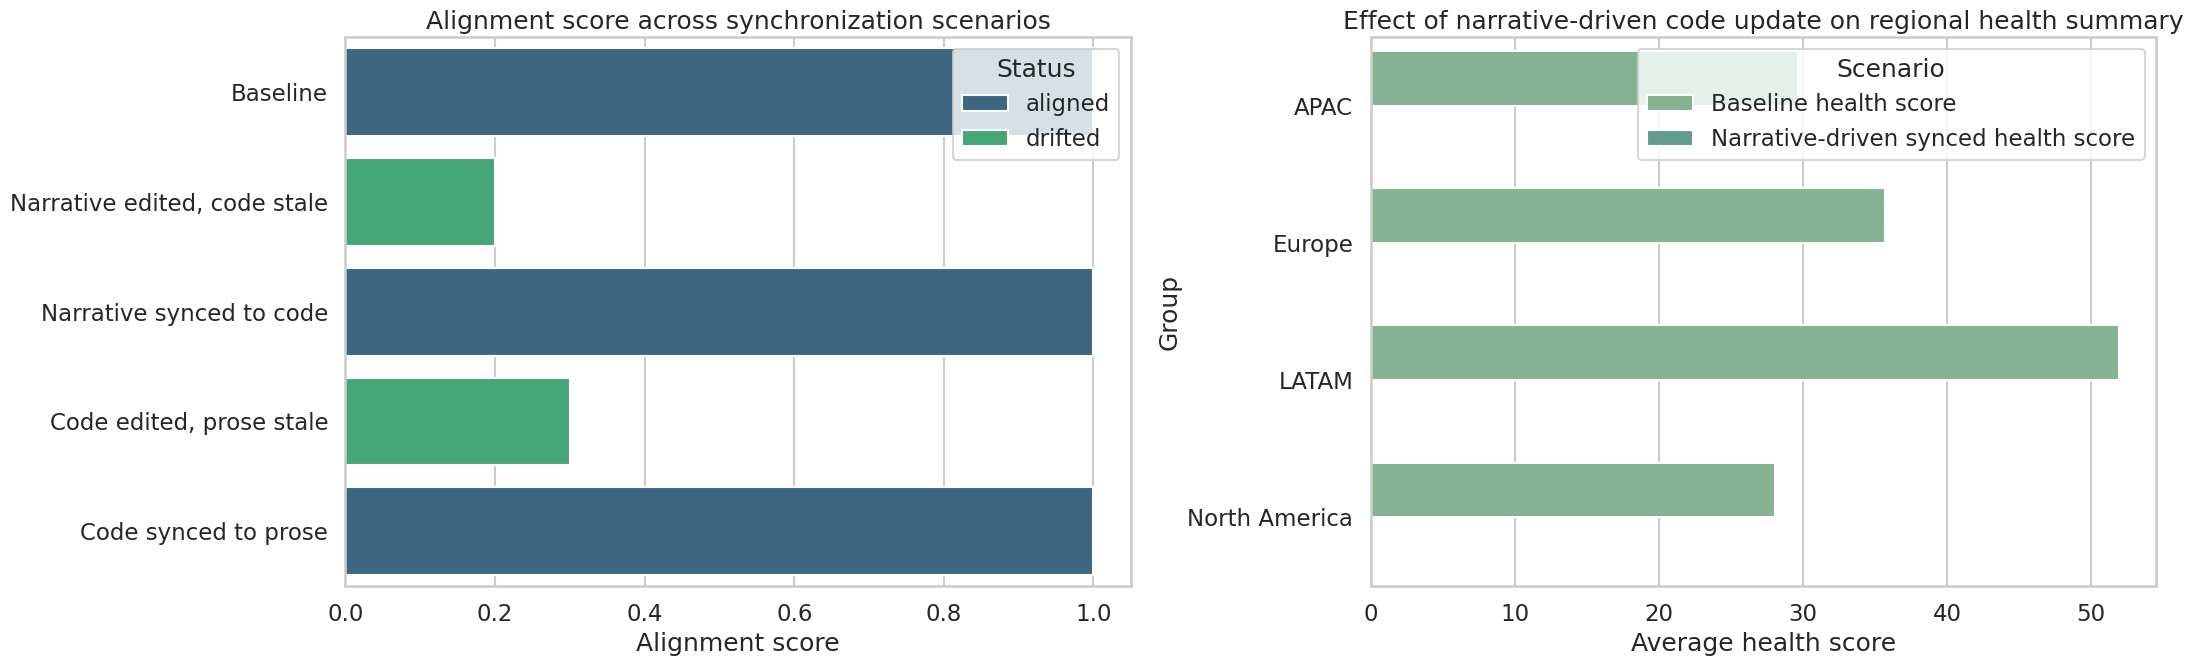

In [6]:
scenario_scores = pd.DataFrame(
    [
        {"scenario": "Baseline", "score": baseline_drift.score, "status": baseline_drift.status},
        {"scenario": "Narrative edited, code stale", "score": markdown_drift.score, "status": markdown_drift.status},
        {"scenario": "Narrative synced to code", "score": markdown_synced_drift.score, "status": markdown_synced_drift.status},
        {"scenario": "Code edited, prose stale", "score": code_drift.score, "status": code_drift.status},
        {"scenario": "Code synced to prose", "score": code_synced_drift.score, "status": code_synced_drift.status},
    ]
)

health_compare = baseline_summary[[baseline_spec.group_by, "health_score"]].rename(
    columns={baseline_spec.group_by: "group", "health_score": "Baseline health score"}
).merge(
    markdown_synced_summary[[baseline_spec.group_by, "health_score"]].rename(
        columns={baseline_spec.group_by: "group", "health_score": "Narrative-driven synced health score"}
    ),
    on="group",
    how="outer",
)
health_compare_long = health_compare.melt(id_vars="group", var_name="scenario", value_name="health_score")

fig, axes = plt.subplots(1, 2, figsize=(22, 7))
sns.barplot(data=scenario_scores, x="score", y="scenario", hue="status", dodge=False, palette="viridis", ax=axes[0])
axes[0].set(title="Alignment score across synchronization scenarios", xlabel="Alignment score", ylabel="")
axes[0].set_xlim(0, 1.05)
axes[0].legend(title="Status")

sns.barplot(data=health_compare_long, x="health_score", y="group", hue="scenario", ax=axes[1])
axes[1].set(title="Effect of narrative-driven code update on regional health summary", xlabel="Average health score", ylabel="Group")
axes[1].legend(title="Scenario")

plt.tight_layout()

## Direct Model Outputs

The core synchronization cells above already use the live endpoint. This section exposes the raw model-generated diff and rewritten narrative directly so the notebook can show the endpoint output itself, not just the downstream analysis result.

In [7]:
ai_code_sync = ai_prose_to_code(edited_markdown, baseline_code, live_client)
ai_markdown_sync = ai_code_to_prose(baseline_markdown, edited_code, live_client)

display(metric_cards([
    {"title": "Endpoint mode", "value": "Live AI", "note": "These outputs came directly from the configured Hugging Face model."},
    {"title": "AI code sync", "value": ai_code_sync["mode"], "note": ai_code_sync["summary"]},
    {"title": "AI prose sync", "value": ai_markdown_sync["mode"], "note": ai_markdown_sync["summary"]},
]))
display(code_panel("Live AI code diff", ai_code_sync["diff"]))
display(callout("Live AI rewritten narrative", ai_markdown_sync["updated_markdown"], tone="info"))

## What This Prototype Covers

This prototype is intentionally simple, but it already demonstrates the core notebook interaction loop for bidirectional synchronization: detect drift, derive an updated counterpart cell, and optionally ask a live model to refine the suggestion when endpoint credentials are available.